# Vyper — Item Effectiveness Volcano Plot

For every upgrade item, test whether holding it is associated with a higher (or lower) win rate
specifically when facing Vyper on the enemy team.

- **x-axis:** log₂(Odds Ratio) — positive means the item is associated with winning against Vyper
- **y-axis:** −log₁₀(BH-adjusted p-value) — higher is more significant
- Uses the full high-rank dataset (avg_badge ≥ 100 on both teams, ~15 k matches)


In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_columns', None)

OTHER_TEAM   = {'Team0': 'Team1', 'Team1': 'Team0'}
HIGH_RANK    = 100
VYPER_ID     = np.int64(58)
MIN_N_WITH   = 20   # min teams holding item while facing Vyper
MIN_N_WITHOUT = 5


In [2]:
items_lookup  = pd.read_parquet('data/public_items.parquet')
heroes_lookup = pd.read_parquet('data/public_heroes.parquet')
for col in items_lookup.columns:
    items_lookup[col] = items_lookup[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)

upgrade_item_ids = set(items_lookup[items_lookup['type'] == 'upgrade']['id'])
item_id_to_name  = items_lookup.set_index('id')['name'].to_dict()
hero_id_to_name  = heroes_lookup.set_index('id')['name'].to_dict()
item_slot        = items_lookup[items_lookup['type'] == 'upgrade'].set_index('name')['slot_type'].to_dict()
print(f'Upgrade items: {len(upgrade_item_ids)}')


Upgrade items: 171


In [3]:
DATA_FILES = ['data/collected_matches.jsonl', 'data/collected_matches_gap.jsonl']

player_rows, item_rows = [], []

for path in DATA_FILES:
    if not os.path.exists(path):
        print(f'  {path} not found — skipping')
        continue
    with open(path) as f:
        for line in f:
            try:
                match = json.loads(line)
            except json.JSONDecodeError:
                continue
            if match['average_badge_team0'] < HIGH_RANK or match['average_badge_team1'] < HIGH_RANK:
                continue
            mid = match['match_id']
            won = match['winning_team']
            for p in match['players']:
                team    = p['team']
                hero_id = np.int64(p['hero_id'])
                player_rows.append({'match_id': mid, 'team': team,
                                    'hero_id': hero_id, 'won': int(team == won)})
                for item in p['items']:
                    iid = np.uint32(item['item_id'])
                    if iid not in upgrade_item_ids:
                        continue
                    item_rows.append({'match_id': mid, 'team': team,
                                      'won': int(team == won), 'item_id': iid,
                                      'held': item['sold_time_s'] == 0})

players_df = pd.DataFrame(player_rows)
items_df   = pd.DataFrame(item_rows)
items_df['item_name'] = items_df['item_id'].map(item_id_to_name)

n_matches = players_df['match_id'].nunique()
print(f'High-rank matches: {n_matches:,}')
print(f'Player rows: {len(players_df):,}  |  Item rows: {len(items_df):,}')


High-rank matches: 15,029
Player rows: 181,248  |  Item rows: 2,886,340


In [4]:
# Per (match, team): flag whether enemy has Vyper
vyper_on_enemy = (
    players_df[players_df['hero_id'] == VYPER_ID][['match_id', 'team']]
    .assign(enemy_vyper=1)
    .assign(team=lambda d: d['team'].map(OTHER_TEAM))
)

outcomes = players_df[['match_id', 'team', 'won']].drop_duplicates()

# Per (match, team, item): did they hold it?
held_wide = (
    items_df[items_df['held']]
    .groupby(['match_id', 'team', 'item_name'])
    .size().gt(0).astype(int)
    .rename('held')
    .reset_index()
    .pivot_table(index=['match_id', 'team'], columns='item_name',
                 values='held', aggfunc='max', fill_value=0)
    .reset_index()
)
held_wide.columns.name = None

team_df = (
    outcomes
    .merge(vyper_on_enemy, on=['match_id', 'team'], how='left')
)
team_df['enemy_vyper'] = team_df['enemy_vyper'].fillna(0).astype(int)

n_facing = team_df['enemy_vyper'].sum()
print(f'Teams facing Vyper: {n_facing:,}  /  {len(team_df):,} total team-slots')


Teams facing Vyper: 2,648  /  30,065 total team-slots


In [5]:
# Merge item holdings into team_df
volcano_df_raw = team_df.merge(held_wide, on=['match_id', 'team'], how='left')
item_cols = [c for c in held_wide.columns if c not in ('match_id', 'team')]
volcano_df_raw[item_cols] = volcano_df_raw[item_cols].fillna(0).astype(int)

facing = volcano_df_raw[volcano_df_raw['enemy_vyper'] == 1]
print(f'Rows where enemy is Vyper: {len(facing):,}')

rows = []
for item in item_cols:
    with_item    = facing[facing[item] == 1]['won']
    without_item = facing[facing[item] == 0]['won']
    n1, n0 = len(with_item), len(without_item)
    if n1 < MIN_N_WITH or n0 < MIN_N_WITHOUT:
        continue

    a = int(with_item.sum())
    b = n1 - a
    c = int(without_item.sum())
    d = n0 - c
    if b == 0 or c == 0:
        continue

    chi2, p, _, _ = chi2_contingency(np.array([[a, b], [c, d]]), correction=False)
    or_val = (a * d) / (b * c)
    rows.append({
        'item':       item,
        'n_with':     n1,
        'n_without':  n0,
        'wr_with':    round(float(with_item.mean()), 3),
        'wr_without': round(float(without_item.mean()), 3),
        'wr_delta':   round(float(with_item.mean() - without_item.mean()), 3),
        'or':         or_val,
        'log2_or':    np.log2(or_val),
        'p_raw':      p,
        'slot_type':  item_slot.get(item, 'unknown'),
    })

vdf = pd.DataFrame(rows)
print(f'Items with enough observations: {len(vdf)}')
display(vdf.sort_values('wr_delta').head(10).round(3))


Rows where enemy is Vyper: 2,648
Items with enough observations: 153


,item,n_with,n_without,wr_with,wr_without,wr_delta,or,log2_or,p_raw,slot_type
81,Metal Skin,637,2011,0.405,0.532,-0.127,0.600,-0.737,0.000,vitality
27,Disarming Hex,372,2276,0.403,0.517,-0.114,0.631,-0.665,0.000,spirit
105,Return Fire,224,2424,0.415,0.509,-0.094,0.685,-0.547,0.007,vitality
52,Guardian Ward,416,2232,0.425,0.515,-0.090,0.697,-0.521,0.001,vitality
64,Improved Spirit,1943,705,0.478,0.566,-0.088,0.701,-0.512,0.000,spirit
126,Spirit Strike,351,2297,0.450,0.509,-0.059,0.790,-0.340,0.040,spirit
103,Restorative Locket,81,2567,0.444,0.503,-0.058,0.791,-0.339,0.300,vitality
74,Long Range,172,2476,0.448,0.505,-0.057,0.795,-0.331,0.147,weapon
84,Mystic Expansion,1004,1644,0.467,0.522,-0.055,0.803,-0.316,0.006,spirit
25,Debuff Reducer,249,2399,0.454,0.506,-0.052,0.811,-0.302,0.117,vitality


In [6]:
_, vdf['p_bh'],   _, _ = multipletests(vdf['p_raw'], method='fdr_bh')
_, vdf['p_bonf'], _, _ = multipletests(vdf['p_raw'], method='bonferroni')
vdf['neg_log10_bh'] = -np.log10(vdf['p_bh'].clip(lower=1e-300))

THRESH_P  = 0.05
THRESH_OR = np.log2(1.2)

def categorise(row):
    if row['p_bh'] >= THRESH_P:
        return 'non-significant'
    if row['log2_or'] >  THRESH_OR:
        return 'beneficial'
    if row['log2_or'] < -THRESH_OR:
        return 'detrimental'
    return 'significant-small-effect'

vdf['category'] = vdf.apply(categorise, axis=1)
print('Category counts:')
print(vdf['category'].value_counts().to_string())
print()
print('Significant items:')
display(vdf[vdf['category'] != 'non-significant']
        .sort_values('log2_or', ascending=False)
        [['item', 'slot_type', 'n_with', 'wr_with', 'wr_without', 'wr_delta', 'or', 'p_bh', 'category']]
        .round(3))


Category counts:
category
non-significant    106
beneficial          40
detrimental          7

Significant items:


,item,slot_type,n_with,wr_with,wr_without,wr_delta,or,p_bh,category
48,Frenzy,weapon,298,0.658,0.481,0.176,2.071,0.000,beneficial
71,Leech,vitality,994,0.604,0.440,0.164,1.942,0.000,beneficial
127,Spiritual Overflow,weapon,319,0.639,0.482,0.157,1.905,0.000,beneficial
104,Restorative Shot,weapon,558,0.620,0.469,0.151,1.845,0.000,beneficial
58,Healing Rite,vitality,797,0.601,0.458,0.143,1.782,0.000,beneficial
91,Phantom Strike,vitality,424,0.616,0.479,0.136,1.739,0.000,beneficial
75,Lucky Shot,weapon,667,0.603,0.467,0.136,1.732,0.000,beneficial
112,Silencer,weapon,307,0.619,0.486,0.133,1.720,0.000,beneficial
113,Siphon Bullets,vitality,611,0.602,0.471,0.132,1.702,0.000,beneficial
59,Healing Tempo,vitality,430,0.605,0.481,0.124,1.650,0.000,beneficial


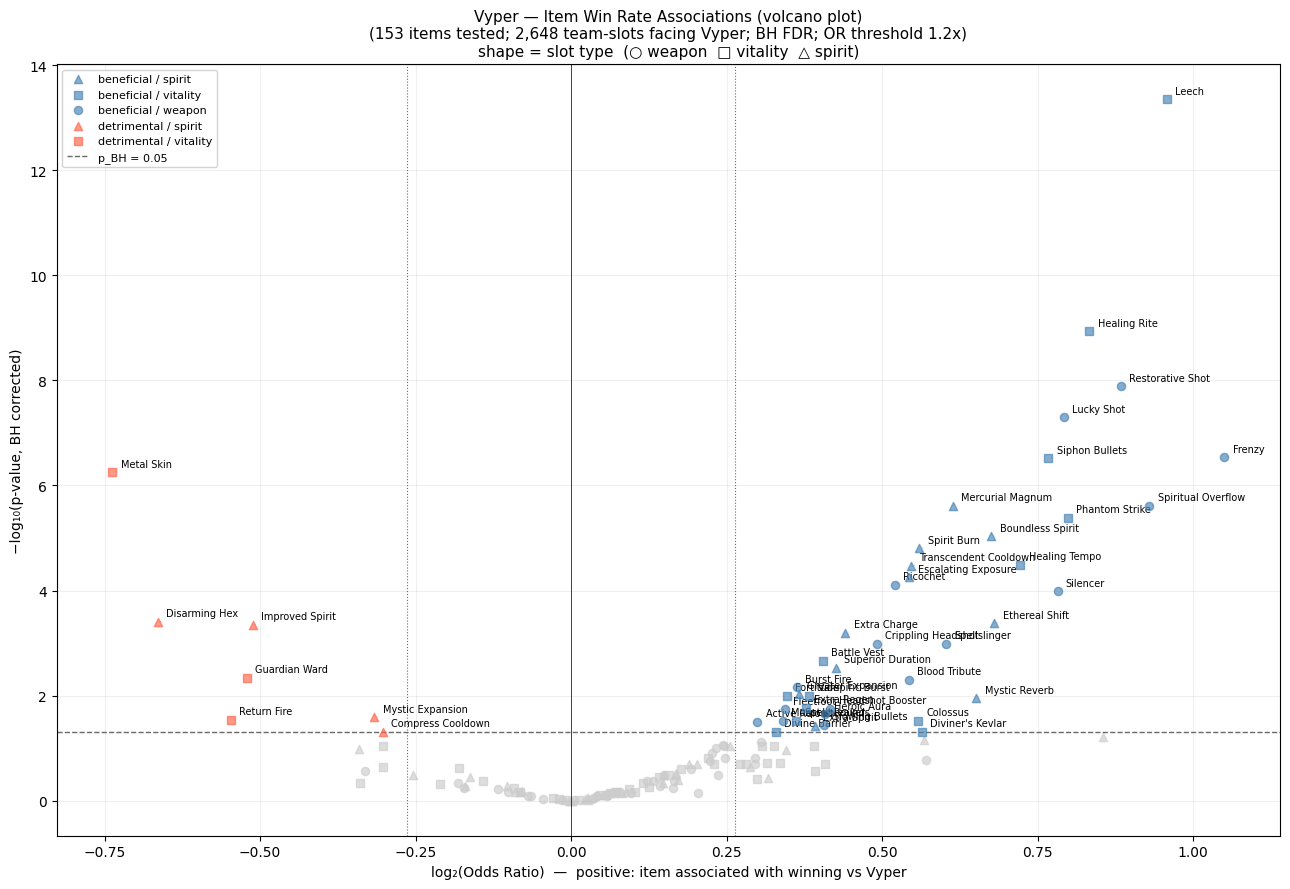

In [7]:
palette = {
    'beneficial':               'steelblue',
    'detrimental':              'tomato',
    'significant-small-effect': 'orange',
    'non-significant':          '#cccccc',
}
z_order = {'non-significant': 1, 'significant-small-effect': 2,
           'detrimental': 3, 'beneficial': 4}

slot_markers = {'weapon': 'o', 'vitality': 's', 'spirit': '^', 'unknown': 'D'}

fig, ax = plt.subplots(figsize=(13, 9))

for cat, grp in vdf.groupby('category'):
    for slot, sgrp in grp.groupby('slot_type'):
        ax.scatter(sgrp['log2_or'], sgrp['neg_log10_bh'],
                   c=palette[cat],
                   marker=slot_markers.get(slot, 'o'),
                   alpha=0.65, s=35,
                   zorder=z_order.get(cat, 2),
                   label=f'{cat} / {slot}' if cat != 'non-significant' else None)

# Reference lines
ax.axhline(-np.log10(THRESH_P), color='dimgrey', linestyle='--',
           linewidth=1, label=f'p_BH = {THRESH_P}')
ax.axvline( THRESH_OR, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(-THRESH_OR, color='dimgrey', linestyle=':', linewidth=0.8)
ax.axvline(0,          color='black',   linewidth=0.5)

# Annotate all significant points
sig = vdf[vdf['category'].isin(['beneficial', 'detrimental', 'significant-small-effect'])]
for _, row in sig.iterrows():
    ax.annotate(
        row['item'],
        xy=(row['log2_or'], row['neg_log10_bh']),
        xytext=(6, 4), textcoords='offset points',
        fontsize=7, color='black',
        arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
    )

ax.set_xlabel('log₂(Odds Ratio)  —  positive: item associated with winning vs Vyper', fontsize=10)
ax.set_ylabel('−log₁₀(p-value, BH corrected)', fontsize=10)
ax.set_title(
    f'Vyper — Item Win Rate Associations (volcano plot)\n'
    f'({len(vdf)} items tested; {n_facing:,} team-slots facing Vyper; BH FDR; OR threshold 1.2x)\n'
    f'shape = slot type  (○ weapon  □ vitality  △ spirit)',
    fontsize=11,
)

# Deduplicate legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8, framealpha=0.85)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Summary table — significant items vs Vyper

In [8]:
sig_items = (
    vdf[vdf['category'] != 'non-significant']
    .sort_values('log2_or', ascending=False)
    [['item', 'slot_type', 'n_with', 'wr_with', 'wr_without', 'wr_delta', 'or', 'p_bh', 'category']]
    .rename(columns={'wr_delta': 'ΔWR', 'or': 'OR', 'p_bh': 'p (BH)', 'n_with': 'n held'})
    .reset_index(drop=True)
)
display(sig_items.round(3))


,item,slot_type,n held,wr_with,wr_without,ΔWR,OR,p (BH),category
0,Frenzy,weapon,298,0.658,0.481,0.176,2.071,0.000,beneficial
1,Leech,vitality,994,0.604,0.440,0.164,1.942,0.000,beneficial
2,Spiritual Overflow,weapon,319,0.639,0.482,0.157,1.905,0.000,beneficial
3,Restorative Shot,weapon,558,0.620,0.469,0.151,1.845,0.000,beneficial
4,Healing Rite,vitality,797,0.601,0.458,0.143,1.782,0.000,beneficial
5,Phantom Strike,vitality,424,0.616,0.479,0.136,1.739,0.000,beneficial
6,Lucky Shot,weapon,667,0.603,0.467,0.136,1.732,0.000,beneficial
7,Silencer,weapon,307,0.619,0.486,0.133,1.720,0.000,beneficial
8,Siphon Bullets,vitality,611,0.602,0.471,0.132,1.702,0.000,beneficial
9,Healing Tempo,vitality,430,0.605,0.481,0.124,1.650,0.000,beneficial
